# 1. Xóa trùng lặp

In [ ]:
from pathlib import Path


# Đường dẫn tới ảnh cần xóa
img_path = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/train/train_img/train1888.png")

# Xóa ảnh
if img_path.exists():
    img_path.unlink()
    print(f"Đã xóa ảnh: {img_path.name}")
else:
    print(f"File không tồn tại: {img_path}")

Đã xóa ảnh: train1888.png


In [2]:
img_path = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/train/train_seg_label/train1888.png")

# Xóa ảnh
if img_path.exists():
    img_path.unlink()
    print(f"Đã xóa ảnh: {img_path.name}")
else:
    print(f"File không tồn tại: {img_path}")

Đã xóa ảnh: train1888.png


In [3]:
from collections import defaultdict
import hashlib
DATASET_PATH = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/train/train_img")
dict_hash = defaultdict(list)
for img in DATASET_PATH.glob("*.png"):
    with open(img, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
    dict_hash[file_hash].append(img)

duplicates = {h: files for h, files in dict_hash.items() if len(files) > 1}

if duplicates:
    print("Phát hiện các file trùng lặp chính xác:")
    for h, files in duplicates.items():
        print(f"- Nhóm trùng ({h}): {files}")
else:
    print("Không tìm thấy file nào trùng lặp chính xác.")

Không tìm thấy file nào trùng lặp chính xác.


# 2. Kiểm tra tập train và test có trùng lặp không

In [4]:
import os

train_files = set()
test_files = set()

for root, _, files in os.walk("data"):
    for f in files:
        path = os.path.join(root, f)
        lower = path.lower()

        if "/train/" in lower:
            train_files.add(os.path.relpath(path, "data"))
        elif "/test/" in lower:
            test_files.add(os.path.relpath(path, "data"))

common = sorted(train_files & test_files)

print("Train unique files:", len(train_files))
print("Test unique files:", len(test_files))
print("Duplicate between train and test:", len(common))
if common:
    print(common[:20])
else:
    print("Không có trùng lặp.")

Train unique files: 0
Test unique files: 0
Duplicate between train and test: 0
Không có trùng lặp.


# 3. Chuyển đổi mask thành polygon 

In [5]:
from pathlib import Path
import cv2

# Thư mục chứa toàn bộ mask
MASK_DIR = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/train/train_seg_label")

# Thư mục lưu polygon
OUTPUT_DIR = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/train/train_labels")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for mask_path in MASK_DIR.glob("*.png"):

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        print("Không đọc được:", mask_path.name)
        continue

    h, w = mask.shape

    # Chuyển mask thành nhị phân
    _, binary = cv2.threshold(
        mask, 0, 255, cv2.THRESH_BINARY
    )

    # Tìm contour
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    lines = []

    for contour in contours:

        # Bỏ vùng quá nhỏ
        if cv2.contourArea(contour) < 10:
            continue

        # Giảm số điểm polygon
        epsilon = 0.002 * cv2.arcLength(contour, True)
        polygon = cv2.approxPolyDP(
            contour, epsilon, True
        )

        if len(polygon) < 3:
            continue

        points = []

        for p in polygon:
            x, y = p[0]

            # Normalize về 0-1
            points.append(x / w)
            points.append(y / h)

        # class_id = 0
        lines.append(
            "0 " + " ".join(
                f"{p:.6f}" for p in points
            )
        )

    # Lưu .txt
    output_path = OUTPUT_DIR / f"{mask_path.stem}.txt"

    with open(output_path, "w") as f:
        f.write("\n".join(lines))

print("Hoàn tất chuyển đổi mask thành polygon.")

Hoàn tất chuyển đổi mask thành polygon.


In [5]:
from pathlib import Path
import cv2

# Thư mục chứa toàn bộ mask
MASK_DIR = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/test/test_seg_label")

# Thư mục lưu polygon
OUTPUT_DIR = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/test/test_labels")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for mask_path in MASK_DIR.glob("*.png"):

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        print("Không đọc được:", mask_path.name)
        continue

    h, w = mask.shape

    # Chuyển mask thành nhị phân
    _, binary = cv2.threshold(
        mask, 0, 255, cv2.THRESH_BINARY
    )

    # Tìm contour
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    lines = []

    for contour in contours:

        # Bỏ vùng quá nhỏ
        if cv2.contourArea(contour) < 10:
            continue

        # Giảm số điểm polygon
        epsilon = 0.002 * cv2.arcLength(contour, True)
        polygon = cv2.approxPolyDP(
            contour, epsilon, True
        )

        if len(polygon) < 3:
            continue

        points = []

        for p in polygon:
            x, y = p[0]

            # Normalize về 0-1
            points.append(x / w)
            points.append(y / h)

        # class_id = 0
        lines.append(
            "0 " + " ".join(
                f"{p:.6f}" for p in points
            )
        )

    # Lưu .txt
    output_path = OUTPUT_DIR / f"{mask_path.stem}.txt"

    with open(output_path, "w") as f:
        f.write("\n".join(lines))

print("Hoàn tất chuyển đổi mask thành polygon.")

Hoàn tất chuyển đổi mask thành polygon.


# 4. Visualize polygon với ảnh

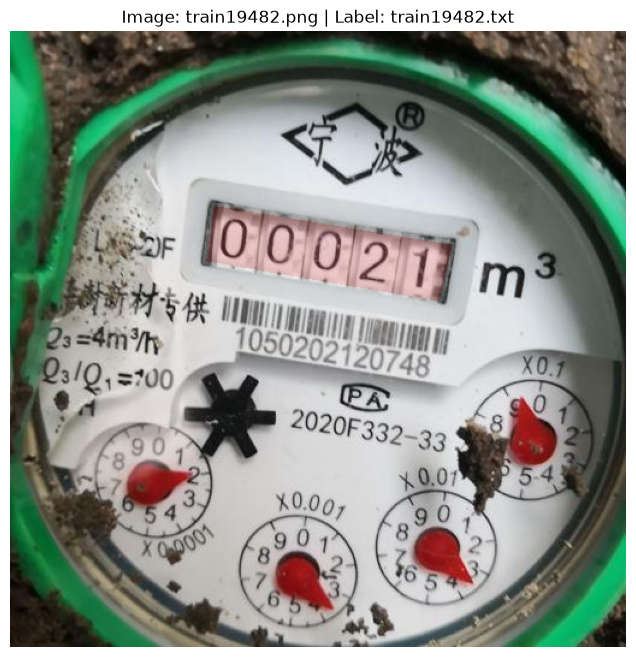

Tổng polygon: 1
Ảnh: /Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/train/train_img/train19482.png
Label: /Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/train/train_labels/train19482.txt


In [4]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_dir = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/train/train_img")
label_dir = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/train/train_labels")

image_path = next(image_dir.glob("*.png"), None)
label_path = label_dir / f"{image_path.stem}.txt"
img_bgr = cv2.imread(str(image_path))


img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape

all_polygons = []
with open(label_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) < 3:
            continue
        values = np.array([float(v) for v in parts[1:]], dtype=np.float32)
        if values.size % 2 != 0 or values.size < 6:
            continue
        pts = values.reshape(-1, 2)
        pts[:, 0] = pts[:, 0] * w
        pts[:, 1] = pts[:, 1] * h
        all_polygons.append(pts.astype(np.int32))

overlay = img_rgb.copy()
for pts in all_polygons:
    cv2.fillPoly(overlay, [pts], color=(255, 0, 0))
    cv2.polylines(overlay, [pts], isClosed=True, color=(255, 255, 255), thickness=2)

vis = cv2.addWeighted(img_rgb, 0.85, overlay, 0.15, 0)

plt.figure(figsize=(12, 8))
plt.imshow(vis)
plt.title(f"Image: {image_path.name} | Label: {label_path.name}")
plt.axis("off")
plt.show()

print(f"Tổng polygon: {len(all_polygons)}")
print(f"Ảnh: {image_path}")
print(f"Label: {label_path}")


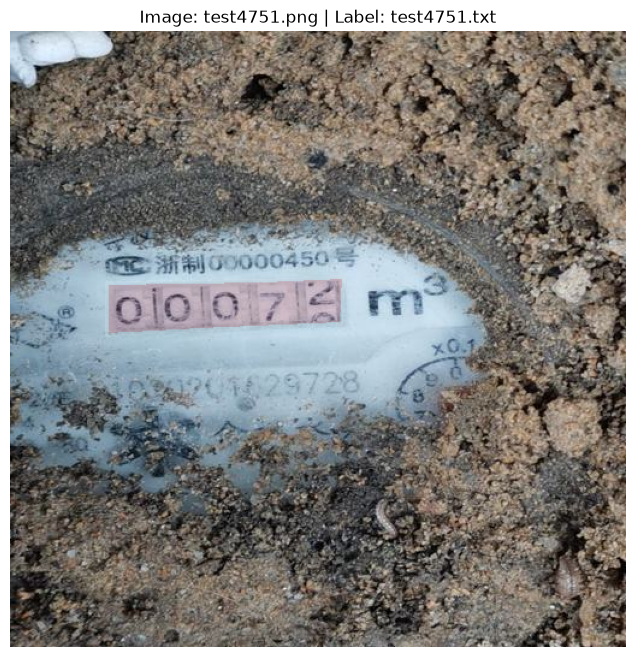

Tổng polygon: 1
Ảnh: /Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/test/test_img/test4751.png
Label: /Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/test/test_labels/test4751.txt


In [8]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_dir = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/test/test_img")
label_dir = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/test/test_labels")

image_path = next(image_dir.glob("*.png"), None)
label_path = label_dir / f"{image_path.stem}.txt"
img_bgr = cv2.imread(str(image_path))


img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape

all_polygons = []
with open(label_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) < 3:
            continue
        values = np.array([float(v) for v in parts[1:]], dtype=np.float32)
        if values.size % 2 != 0 or values.size < 6:
            continue
        pts = values.reshape(-1, 2)
        pts[:, 0] = pts[:, 0] * w
        pts[:, 1] = pts[:, 1] * h
        all_polygons.append(pts.astype(np.int32))

overlay = img_rgb.copy()
for pts in all_polygons:
    cv2.fillPoly(overlay, [pts], color=(255, 0, 0))
    cv2.polylines(overlay, [pts], isClosed=True, color=(255, 255, 255), thickness=2)

vis = cv2.addWeighted(img_rgb, 0.85, overlay, 0.15, 0)

plt.figure(figsize=(12, 8))
plt.imshow(vis)
plt.title(f"Image: {image_path.name} | Label: {label_path.name}")
plt.axis("off")
plt.show()

print(f"Tổng polygon: {len(all_polygons)}")
print(f"Ảnh: {image_path}")
print(f"Label: {label_path}")


# 5. Phân chia train thành train và validation

In [11]:
from pathlib import Path
import shutil
import random

ROOT = Path("/Users/mac/MeterReadAI/data/Word_Wheel_Water_Meter")

TRAIN_IMAGES = ROOT / "images/train"
TRAIN_LABELS = ROOT / "labels/train"

VAL_IMAGES = ROOT / "images/val"
VAL_LABELS = ROOT / "labels/val"

VAL_IMAGES.mkdir(parents=True, exist_ok=True)
VAL_LABELS.mkdir(parents=True, exist_ok=True)


# =========================
# 1. LẤY CẶP IMAGE + LABEL
# =========================

pairs = []

for image_path in TRAIN_IMAGES.iterdir():

    if not image_path.is_file():
        continue

    if image_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
        continue

    label_path = TRAIN_LABELS / f"{image_path.stem}.txt"

    if label_path.exists():
        pairs.append((image_path, label_path))
    else:
        print("Thiếu label:", image_path.name)


print("Tổng train:", len(pairs))


# =========================
# 2. SHUFFLE
# =========================

random.seed(42)
random.shuffle(pairs)


# =========================
# 3. LẤY 10% LÀM VALIDATION
# =========================

val_size = int(len(pairs) * 0.1)

val_pairs = pairs[:val_size]


print("Validation:", len(val_pairs))
print("Train còn lại:", len(pairs) - len(val_pairs))


# =========================
# 4. COPY SANG VAL
# =========================

for image_path, label_path in val_pairs:

    shutil.copy2(
        image_path,
        VAL_IMAGES / image_path.name
    )

    shutil.copy2(
        label_path,
        VAL_LABELS / label_path.name
    )


# =========================
# 5. XÓA KHỎI TRAIN
# =========================

for image_path, label_path in val_pairs:

    image_path.unlink()
    label_path.unlink()


print("\nĐã chia Train / Val")

Tổng train: 32706
Validation: 3270
Train còn lại: 29436

Đã chia Train / Val
